In [1]:
# 73790d373b1141e68bac38ab50ddfbc2

In [2]:
import time
import math

import matplotlib.pyplot as plt
from torch.profiler import tensorboard_trace_handler

plt.switch_backend('agg')
import matplotlib.ticker as ticker
import numpy as np

def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)

In [3]:
import torch
import torch.nn as nn
from torch import optim
from torch.utils.tensorboard import SummaryWriter
import time
import math
import matplotlib.pyplot as plt
import random
%matplotlib inline

def train_epoch(dataloader, model, optimizer, criterion, writer, teacher_forcing):
    total_loss = 0
    for i, data in enumerate(dataloader):
        # if i%20000==0:
        #     print(i)
        # print(data)
        input_tensor, target, de, dgs, idx = data
        # print(idx)
        print("DE:", de)
        print("DGS:", dgs)
        # print("TEACHER FORCING:", teacher_forcing)
        
        input_tensor = input_tensor.squeeze(0)
        target_indices = target[0].squeeze(0)
        target_classes = target[1].squeeze(0)
        
        if i==0:
            try:
                writer.add_graph(model, torch.rand(*input_tensor.shape).to(device))
            except Exception as e:
                print(e)

        optimizer.zero_grad()
        print("INPUT:", input_tensor[:, 0:5])
        print("TARGET:", target_indices)
        # print(target_classes[:, 0:5])
        if teacher_forcing:
            _, outputs = model(input_tensor, target_tensor=target_indices)
        else:
            _, outputs = model(input_tensor)
            rows_to_add = target_indices.shape[0] - outputs.shape[0]
            if rows_to_add > 0:
                # outputs = torch.cat((outputs, torch.zeros(rows_to_add, outputs.shape[1]).to(device)), dim=0)
                outputs = torch.cat((outputs, torch.full((rows_to_add, outputs.shape[1]), -1).to(device)), dim=0)   # <PAD> tokens
            else:
                outputs = outputs[:target_indices.shape[0]]
        
        print("OUT:", outputs)
        loss = criterion(outputs, target_indices)
        # print("LOSS:", loss)
        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def train(train_dataloader, model, n_epochs, learning_rate=0.001, teacher_forcing_prob=0.7, print_every=100, plot_every=100):
    print("Training...")
    start = time.time()
    plot_losses = []
    print_loss_total = 0
    plot_loss_total = 0
    random.seed(42)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss(ignore_index=-1)
    
    writer = SummaryWriter()
    epoch_losses = []

    for epoch in range(1, n_epochs + 1):
        teacher_forcing = random.random() < teacher_forcing_prob
        loss = train_epoch(train_dataloader, model, optimizer, criterion, writer, teacher_forcing)
        print_loss_total += loss
        plot_loss_total += loss

        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, epoch / n_epochs), epoch, epoch / n_epochs * 100, print_loss_avg))
            writer.add_scalar('Training Loss', print_loss_avg, epoch)

        if epoch % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0
            writer.add_scalar('Plot Loss', plot_loss_avg, epoch)
            
        epoch_losses.append(loss)

    showPlot(plot_losses)
    writer.close()
    
    return epoch_losses
    
def evaluate(model, sentence):
    with torch.no_grad():
        input_tensor = model.sentence2vec(sentence)
        outputs, _ = model(input_tensor)      
        decoded_words = model.decode_sequence(outputs)
        
    return decoded_words

def evaluate_randomly(model, dataloader, n=10):
    for i, data in zip(range(n), dataloader):
        input_tensor, target, de, dgs, idx = data
        input_tensor = input_tensor.squeeze(0)
        
        de, dgs = de[0], dgs[0]
        
        print('>', de)
        print('=', dgs)
        output_words = evaluate(model, de)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')
        
def show_state_dict(model):
    print("Model's state_dict:")
    for param_tensor in model.state_dict():
        print(param_tensor, "\t", model.state_dict()[param_tensor].size())
        
def plot_training_progress(losses):
    plt.figure()
    plt.plot(losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Progress')
    plt.legend()
    plt.grid(True)
    plt.show()

Training...
DE: (' Es läuft so schleppend auf und ab, jetzt ist es vielleicht etwas besser. ',)
DGS: ('ABLAUF1^ $PROD* JETZT1 BESSER1* ',)
INPUT: tensor([[-0.0719, -0.0793,  0.1273,  0.0919, -0.0550],
        [ 0.0123, -0.0354,  0.1291,  0.0260, -0.0051],
        [ 0.0380, -0.0031,  0.0114,  0.0155, -0.0305],
        [ 0.0175,  0.0232, -0.0161,  0.0144, -0.0029],
        [ 0.0044, -0.0175,  0.0701,  0.0681, -0.0164],
        [-0.0541,  0.0290,  0.1001,  0.0021,  0.0049],
        [-0.1855, -0.0383, -0.0624,  0.1405,  0.0560],
        [-0.0410, -0.0060, -0.0196,  0.0054, -0.0078],
        [-0.0039,  0.0173,  0.0128, -0.0083,  0.0017],
        [-0.0541,  0.0290,  0.1001,  0.0021,  0.0049],
        [-0.0237, -0.0647,  0.0835,  0.0136, -0.0420],
        [-0.0043,  0.0112, -0.0235, -0.0073, -0.0016],
        [-0.0029,  0.0229, -0.0006,  0.0564,  0.0051],
        [-0.0039, -0.0120, -0.0084, -0.0445,  0.0017],
        [-0.0238,  0.0072, -0.0694, -0.0445, -0.0116]], device='cuda:0')
TARGET: ten

<Figure size 640x480 with 0 Axes>

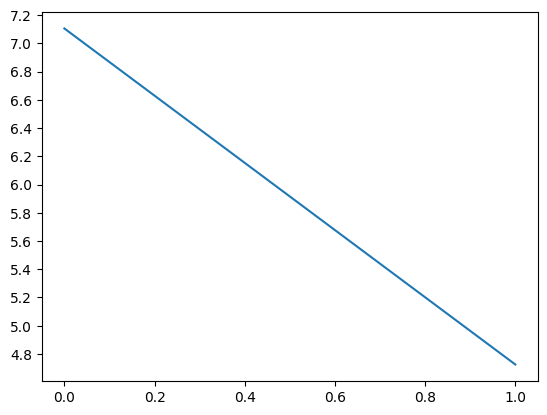

In [4]:
from torch.utils.data import DataLoader
from dataset import DgsDataset
from seq2seq import Seq2Seq

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ds = DgsDataset('vocab/translations/dgs_korpus.pkl', simplify=True)
subset = torch.utils.data.Subset(ds, list(range(0, 50)))
dl = DataLoader(subset, batch_size=1, shuffle=True)

hidden_size = 128

s2s = Seq2Seq(ds.vocabulary, ds.max_tokens, hidden_size=hidden_size).to(device)
# s2s.load_state_dict(torch.load("state_dict.pt"))
# show_state_dict(s2s)

losses = train(dl, s2s, 2, learning_rate=0.0005, teacher_forcing_prob=0.5, print_every=1, plot_every=1)

In [5]:
s2s.eval()
torch.save(s2s.state_dict(), 'state_dict.pt')
evaluate_randomly(s2s, dl)

>  Darum ist es immer so, dass es viele Gehörlose/ 
= DARUM1* IMMER4A* VIEL1A TAUB-GEHÖRLOS1A 
< ICH1 ICH1 <EOS>

>  Ich arbeitete also in dieser Firma, aber ich hatte ein Angebot einer anderen Firma, bei der viele gehörlose Kollegen arbeiten. 
= ICH1 ARBEITEN2* GEFÜHL3 INNEN1B^* || GEWESEN1 || $NUM-EINER1A:1d* || FIRMA1A || ANDERS1 || GEHÖREN1^* AUF-PERSON1* ANGEBOT1B || $INDEX1 VIEL1A TAUB-GEHÖRLOS1A KOLLEGE1A* 
< ICH1 ICH1 ICH1 <EOS>

>  Darum nehme ich das so hin, wie es ist. 
= ICH1 DARUM1* ICH1 $GEST^ ICH1 
< ICH1 ICH1 <EOS>

>  Wenn ich gut gelaunt bin, dann ist es einfacher, in Kontakt miteinander zu kommen. 
= WENN1A GUT1* LACHEN1* ZUSAMMENHANG1A 
< ICH1 ICH1 <EOS>

>  Ich nahm das so hin und da waren wir nur zwei Gehörlose, das wars. 
= ICH1 $GEST-ABWINKEN1^* NUR2A TAUB-GEHÖRLOS1A BEIDE2A* ENDE1^* 
< ICH1 ICH1 <EOS>

>  Du kannst mit einem Thema anfangen. Es liegt bei dir, über was du erzählst. 
= ICH1 THEMA1 ZUSAMMENHANG1A FIRMA1A MEIN1 FIRMA1A 
< ICH1 ICH1 <EOS>

>  Was ich